# 02 Exploratory Data Analysis
Explore churn patterns across contracts, billing, services, and numeric customer attributes.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")


In [2]:
DATA_PATH = "../data/raw/Telco_customer_churn.xlsx"

df = pd.read_excel(DATA_PATH)
df.head()


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [3]:
df = df.drop(columns=['CustomerID', 'Count', 'Country', 'State'])
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'] = df['Total Charges'].fillna(df['Total Charges'].median())
df.head()


,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [4]:
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(exclude='object').columns

print("Categorical columns:", list(cat_cols))
print("Numerical columns:", list(num_cols))


Categorical columns: ['City', 'Lat Long', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Churn Label', 'Churn Reason']
Numerical columns: ['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value', 'Churn Score', 'CLTV']


/var/folders/sy/fn2qgtkx67g908zk5blm6svw0000gn/T/ipykernel_27824/3596328971.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [5]:
churn_rate = df['Churn Value'].mean() * 100
print(f"Overall churn rate: {churn_rate:.2f}%")

df['Churn Label'].value_counts(normalize=True) * 100


Overall churn rate: 26.54%


Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [6]:
pd.crosstab(df['Contract'], df['Churn Label'], normalize='index') * 100


Churn Label,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [7]:
pd.crosstab(df['Paperless Billing'], df['Churn Label'], normalize='index') * 100


Churn Label,No,Yes
Paperless Billing,,
No,83.669916,16.330084
Yes,66.434908,33.565092


In [8]:
eda_categorical_cols = [
    'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
    'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup',
    'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies',
    'Contract', 'Paperless Billing', 'Payment Method'
]

for col in eda_categorical_cols:
    print(f"\n===== {col} =====")
    ct = pd.crosstab(df[col], df['Churn Label'], normalize='index') * 100
    print(ct.round(2))



===== Gender =====
Churn Label     No    Yes
Gender                   
Female       73.08  26.92
Male         73.84  26.16

===== Senior Citizen =====
Churn Label        No    Yes
Senior Citizen              
No              76.39  23.61
Yes             58.32  41.68

===== Partner =====
Churn Label     No    Yes
Partner                  
No           67.04  32.96
Yes          80.34  19.66

===== Dependents =====
Churn Label     No    Yes
Dependents               
No           67.45  32.55
Yes          93.48   6.52

===== Phone Service =====
Churn Label       No    Yes
Phone Service              
No             75.07  24.93
Yes            73.29  26.71

===== Multiple Lines =====
Churn Label          No    Yes
Multiple Lines                
No                74.96  25.04
No phone service  75.07  24.93
Yes               71.39  28.61

===== Internet Service =====
Churn Label          No    Yes
Internet Service              
DSL               81.04  18.96
Fiber optic       58.11  41.89
No 

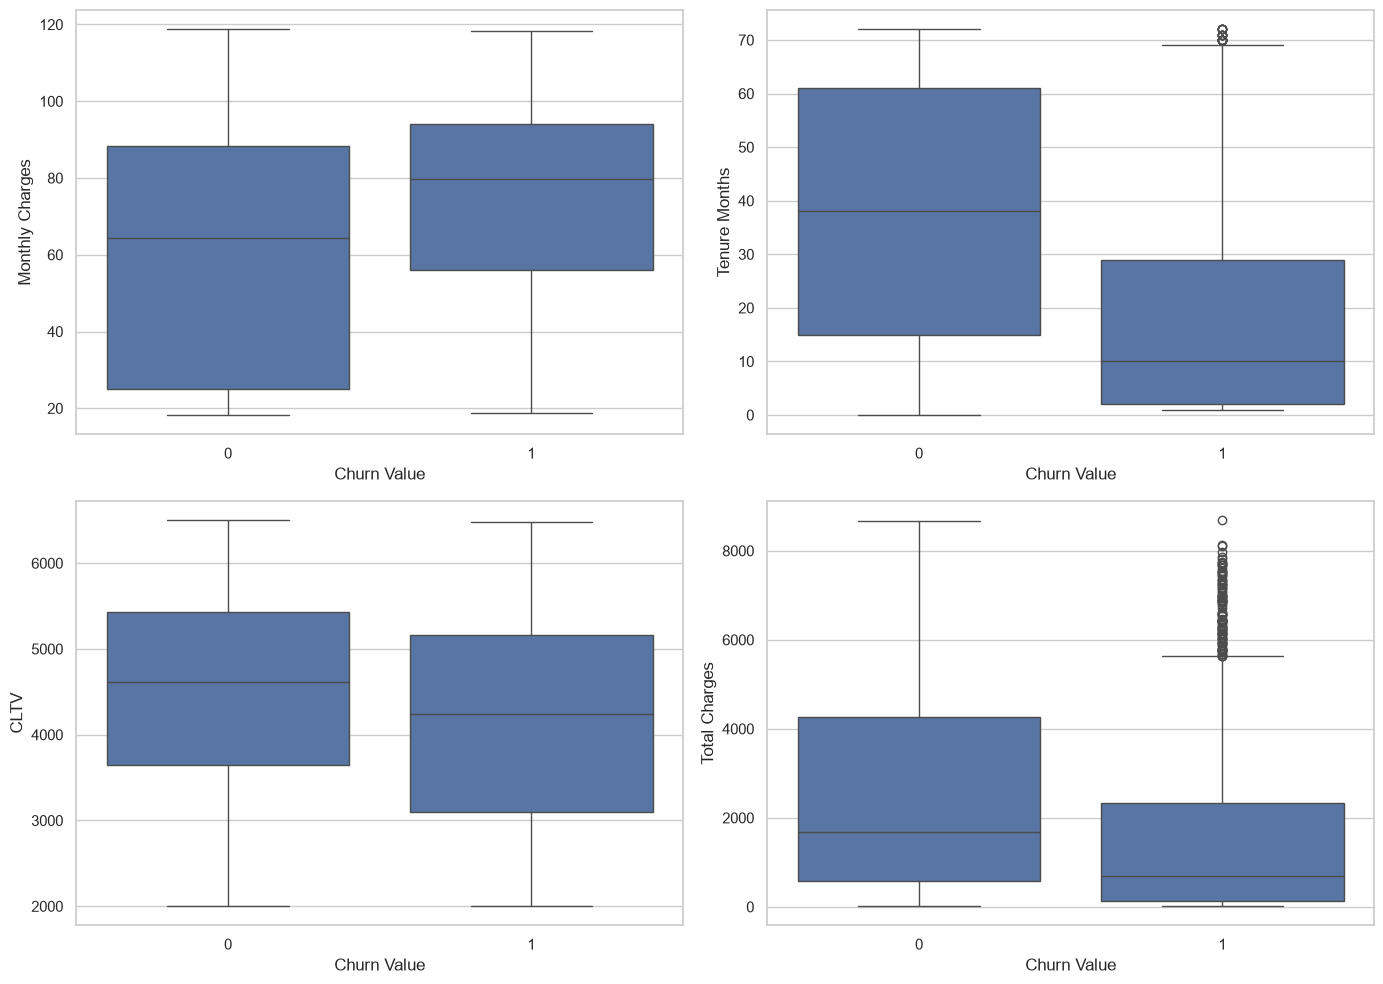

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(x='Churn Value', y='Monthly Charges', data=df, ax=axes[0, 0])
sns.boxplot(x='Churn Value', y='Tenure Months', data=df, ax=axes[0, 1])
sns.boxplot(x='Churn Value', y='CLTV', data=df, ax=axes[1, 0])
sns.boxplot(x='Churn Value', y='Total Charges', data=df, ax=axes[1, 1])

plt.tight_layout()
plt.show()


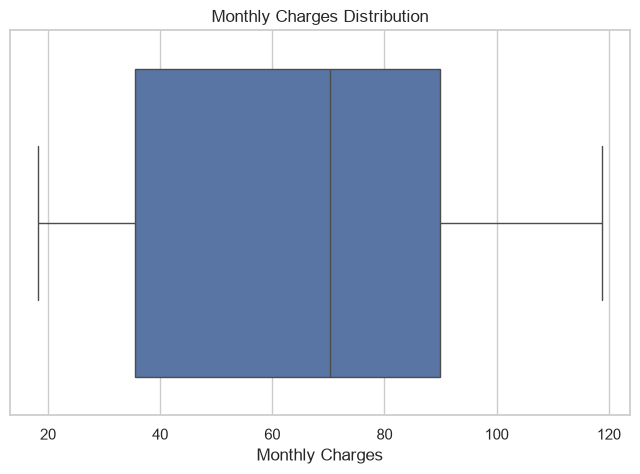

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Monthly Charges'])
plt.title('Monthly Charges Distribution')
plt.show()


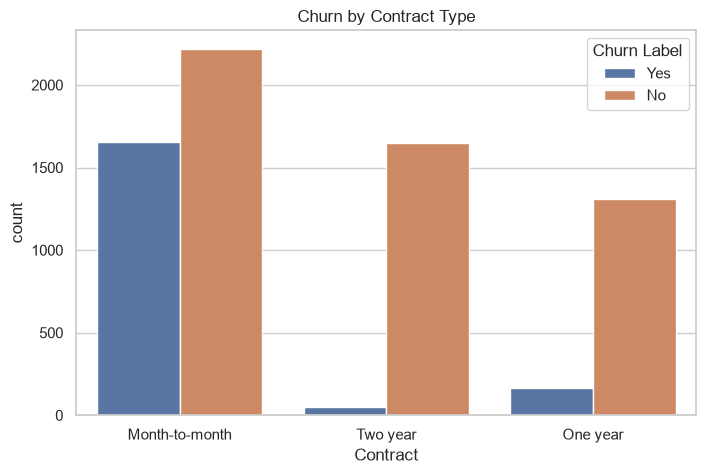

In [11]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn Label')
plt.title('Churn by Contract Type')
plt.show()


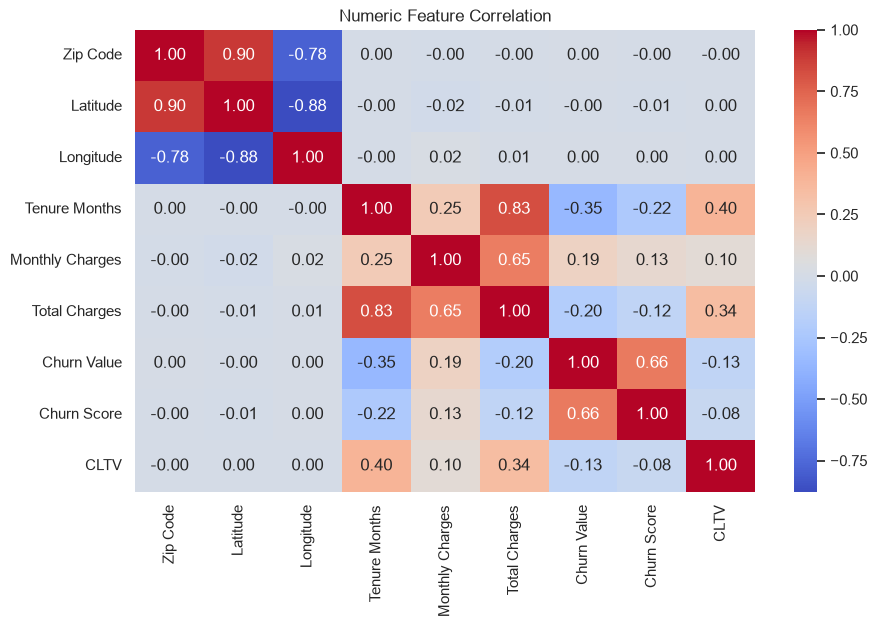

In [12]:
plt.figure(figsize=(10, 6))
numeric_corr = df[['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value', 'Churn Score', 'CLTV']].corr()
sns.heatmap(numeric_corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Numeric Feature Correlation')
plt.show()


In [13]:
df.groupby('Churn Value')['Latitude'].mean()


Churn Value
0    36.287436
1    36.268614
Name: Latitude, dtype: float64